In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import seaborn as sns
from matplotlib.colors import Normalize
import textwrap
import pyarrow.feather as feather
import matplotlib.gridspec as gridspec
import os
import geopandas as gpd
import contextily as ctx
import string
from sklearn.linear_model import LinearRegression
import pyreadr

In [ ]:
# load rr data
base_dir = 'XXXX'
file_list = ['revision_rr_sum.csv']
df = pd.DataFrame()
for f in file_list:
    df = pd.concat([df, pd.read_csv(os.path.join(base_dir,f))], ignore_index=True)
# drop duplicate rows
df = df.drop_duplicates()
# remove rows with hw_or_added as 0
df = df[df['hw_or_added'] != "0"]
    

In [3]:
hoa_list = df['hw_or_added'].unique().tolist()
hoa_list.sort()
disease_list = df['disease'].unique().tolist()
disease_list.sort()
category_list = df['category'].unique().tolist()
category_list.sort()
# for each category_list, get the corresponding subgroup and make a dictionary
subcategory_dict = {}
for cat in category_list:
    subcat_list = df[df['category'] == cat]['subgroup'].unique().tolist()
    subcat_list.sort()
    subcategory_dict[cat] = subcat_list
duration_list = df['duration'].unique().tolist()
duration_list.sort()
threshold_list = df['threshold'].unique().tolist()
threshold_list.sort()


In [5]:
look_up_table ={
    'DEM': ['F00', 'F01', 'F02', 'F03'],
    'SUB': ['F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19'],
    'SCHZ': ['F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29'],
    'MAN': ['F30'],
    'BPAD': ['F31'],
    'DEP': ['F32', 'F33'],
    'PMD': ['F34'],
    'OMD': ['F38'],
    'UMD': ['F39'],
    'ANX': ['F40', 'F41'],
    'OCD': ['F42'],
    'RSAD': ['F43'],
    'DCD': ['F44'],
    'SFD': ['F45'],
    'OND': ['F48'],
    'PD': ['F60', 'F61', 'F62', 'F63', 'F64', 'F65', 'F66', 'F68', 'F69'],
    'MR': ['F70', 'F71', 'F72', 'F73', 'F78', 'F79'],
    'DPD': ['F80', 'F81', 'F82', 'F83', 'F84', 'F88', 'F89'],
    'BED': ['F90', 'F91', 'F92', 'F93', 'F94', 'F95', 'F98'],
    'UMD': ['F99']
}

disease_lookup = {
    'DEM': 'Dementia',
    'SUB': 'Substance use',
    'SCHZ': 'Schizophrenia',
    'MAN': 'Manic episode',
    'BPAD': 'Bipolar affective disorder',
    'DEP': 'Depression',
    'PMD': 'Persistent mood [affective] disorders',
    'OMD': 'Other mood [affective] disorders',
    'UMD': 'Unspecified mood [affective] disorder',
    'ANX': 'Anxiety',
    'OCD': 'Obsessive-compulsive disorder',
    'RSAD': 'Reaction to severe stress, and adjustment disorders',
    'DCD': 'Dissociative [conversion] disorders',
    'SFD': 'Somatoform disorders',
    'OND': 'Other neurotic disorders',
    'PD': 'Personality disorders',
    'MR': 'Mental retardation',
    'DPD': 'Disorders of psychological development',
    'BED': 'Behavioral and emotional disorders with onset usually occurring in childhood and adolescence',
    'UMD': 'Unspecified mental disorder'
}

In [7]:
df_sensitivity = df.copy()
df_sensitivity = df_sensitivity.drop(columns=["Unnamed: 0"])
df_sensitivity = df_sensitivity.drop_duplicates()
df_sensitivity = df_sensitivity[df_sensitivity['lag'] == 0]
df_sensitivity = df_sensitivity[df_sensitivity['disease'] == 'all']
sub_group_list = ['all','female','male','0-19','20-59','60+']


In [ ]:
figure_base_dir = '/'

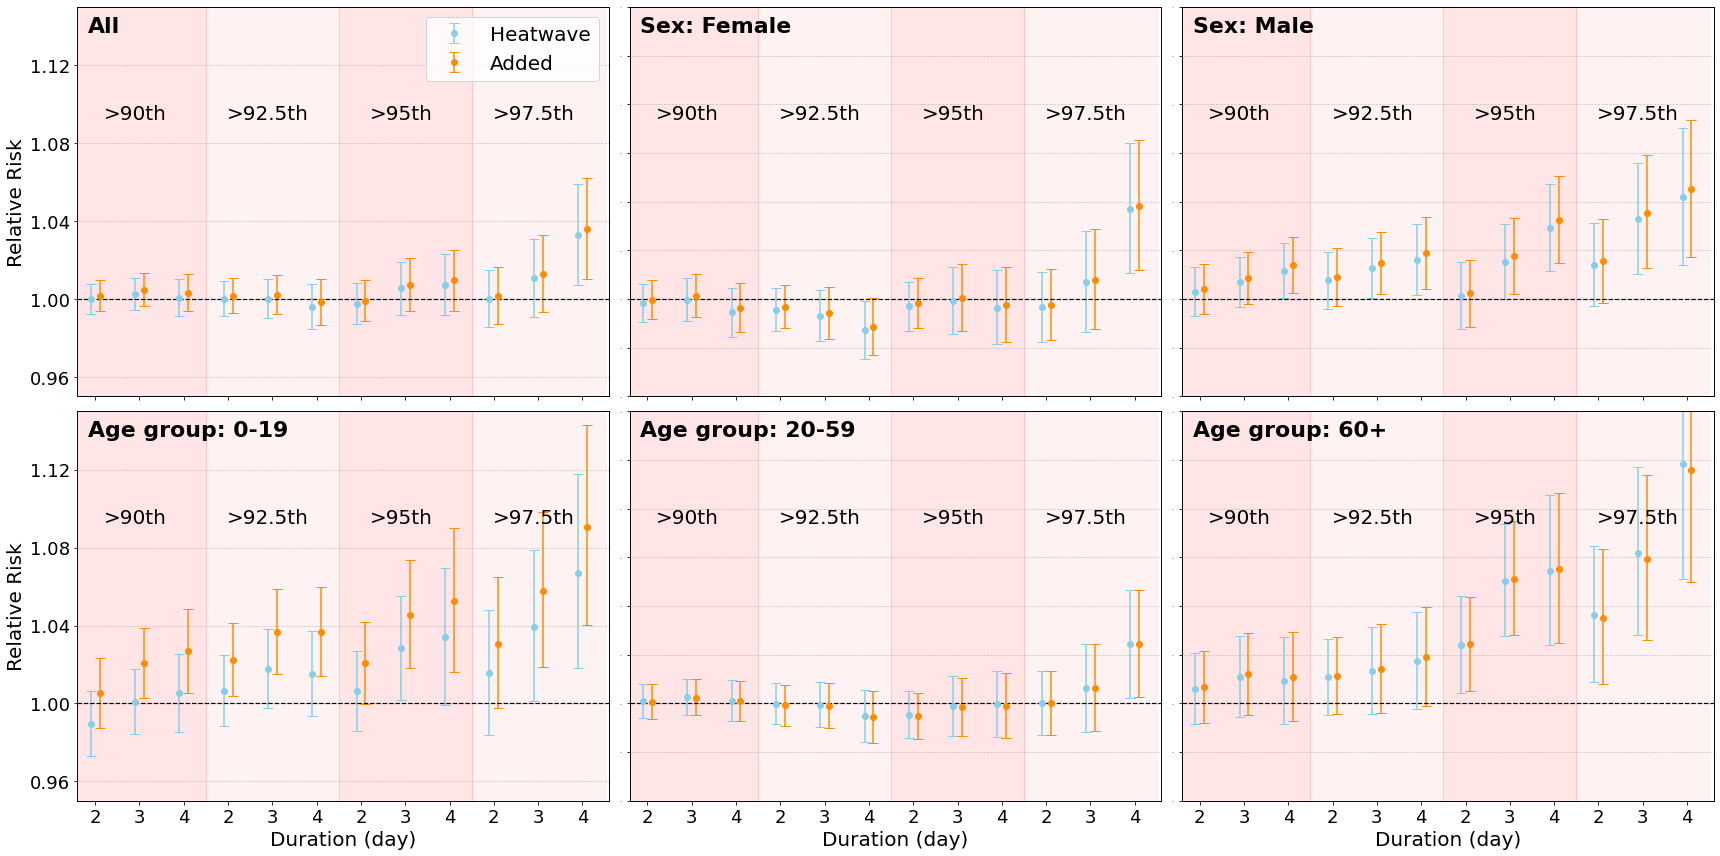

In [10]:
# 3 * 2 plot, first row all population, female, male; second row age groups 0-19, 20-59, 60+
fig, axs = plt.subplots(2, 3, figsize=(24, 12))
for index_sub, sub in enumerate(sub_group_list):
    df_sensitivity_lag0 = df_sensitivity[df_sensitivity['subgroup'] == sub]
    # fig, ax = plt.subplots(figsize=(12, 9))
    ax = axs.flatten()[index_sub]
    # Sort and prepare the data
    df_sensitivity_lag0 = df_sensitivity_lag0.sort_values(by=['threshold', 'duration'])
    df_sensitivity_lag0['cat'] = df_sensitivity_lag0['threshold'].astype(str) + ' ' + df_sensitivity_lag0['duration'].astype(str)
    df_sensitivity_lag0_hw = df_sensitivity_lag0[df_sensitivity_lag0['hw_or_added'] == 'hw'].sort_values(by='cat')
    df_sensitivity_lag0_added = df_sensitivity_lag0[df_sensitivity_lag0['hw_or_added'] == 'added'].sort_values(by='cat')
    # Number of categories
    n = len(df_sensitivity_lag0_hw)
    # Positioning for error bars (centered and closer)
    bar_width = 0.2
    indices = np.arange(n)
    df_sensitivity_lag0_hw['order'] = indices - bar_width / 2
    df_sensitivity_lag0_added['order'] = indices + bar_width / 2
    # Plotting with error bars, adjusted colors for appeal
    ax.errorbar(df_sensitivity_lag0_hw['order'], df_sensitivity_lag0_hw['RR'], 
                yerr=[df_sensitivity_lag0_hw['RR'] - df_sensitivity_lag0_hw['RR_low'], df_sensitivity_lag0_hw['RR_high'] - df_sensitivity_lag0_hw['RR']], 
                fmt='o', color='skyblue',
                label='Heatwave', capsize=5)
    ax.errorbar(df_sensitivity_lag0_added['order'], df_sensitivity_lag0_added['RR'], 
                yerr=[df_sensitivity_lag0_added['RR'] - df_sensitivity_lag0_added['RR_low'], df_sensitivity_lag0_added['RR_high'] - df_sensitivity_lag0_added['RR']], 
                fmt='o', color='darkorange',
                label='Added', capsize=5)
    # Add periodic shading for different thresholds
    unique_thresholds = df_sensitivity_lag0_hw['threshold'].unique()
    for i, threshold in enumerate(unique_thresholds):
        shade_indices = df_sensitivity_lag0_hw[df_sensitivity_lag0_hw['threshold'] == threshold]['order'] + bar_width / 2
        ax.axvspan(shade_indices.min() - 0.5, shade_indices.max() + 0.5, color='red', alpha=0.1 if i % 2 == 0 else 0.05)
    # Title and labels with improved formatting
    # ax.set_title('Sensitivity Analysis', fontsize=18, weight='bold', loc='left')
    # ax.set_xlabel('Duration (day)', fontsize=20)
    # ax.set_ylabel('Relative Risk', fontsize=20)
    # ax.set_title(f'Subgroup: {sub}', fontsize=22, weight='bold', loc='left')
    if sub == 'all':
        ax.set_title('All', fontsize=22, weight='bold', loc='left', y =0.92,x=0.02)
        
    if sub == 'female' or sub == 'male':
        ax.set_title('Sex: ' + sub.capitalize(), fontsize=22, weight='bold', loc='left', y =0.92,x=0.02)
    if sub == '0-19' or sub == '20-59' or sub == '60+':
        ax.set_title('Age group: ' + sub, fontsize=22, weight='bold', loc='left', y =0.92,x=0.02)
    if index_sub >=3:
        ax.set_xlabel('Duration (day)', fontsize=20)
    if index_sub ==0 or index_sub ==3:
        ax.set_ylabel('Relative Risk', fontsize=20)


    # Add threshold text in the center of the shaded area under the duration x-label
    for i, threshold in enumerate(unique_thresholds):
        shade_indices = df_sensitivity_lag0_hw[df_sensitivity_lag0_hw['threshold'] == threshold]['order']
        mid_point = (shade_indices.min() + shade_indices.max()) / 2
        if i % 2 == 0:
            ax.text(mid_point, 0.75, 
                    ">" + str(int(threshold)) + 'th',
                    ha='center', va='top', fontsize=20, transform=ax.get_xaxis_transform())
        else:
            ax.text(mid_point, 0.75, 
                ">" + str(threshold) + 'th',
                ha='center', va='top', fontsize=20, transform=ax.get_xaxis_transform())
    # Hide the secondary x-axis
    ax2 = ax.twiny()
    ax2.set_xticks([])  # Remove ticks on the secondary axis
    ax2.set_xticklabels([])  # Remove labels on the secondary axis

    # Legend and grid settings
    if index_sub == 0:
        ax.legend(fontsize=20)
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.set_xlim(-bar_width*2, n - 2*bar_width)  # Adjust the x-axis limits for better visibility
    ax.set_ylim(0.95, 1.15)  # Adjust the y-axis limits for better visibility
    #add y = 1 line
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2)
    # Adjust the layout to fit all elements
    # Set x-ticks for duration
    ax.set_xticks(indices)
    if index_sub >= 3:
        ax.set_xticklabels(df_sensitivity_lag0_hw['duration'],  ha='center', fontsize=18)
    else:
        ax.set_xticklabels([],  ha='center', fontsize=18)
    if index_sub ==0 or index_sub ==3:
        ticks = [0.96, 1.00, 1.04, 1.08,1.12]
        labels = ['0.96', '1.00', '1.04', '1.08', '1.12']

        ax.set_yticks(ticks)
        ax.set_yticklabels(labels, fontsize=18)
        ax.tick_params(axis='y', labelsize=18)
    else:
        # remove y tick labels
        ax.tick_params(axis='y', labelsize=False)

plt.tight_layout()
# export the figure as pdf and png called Figure_S6
plt.savefig(figure_base_dir + 'Figure_S6.pdf', dpi=600, bbox_inches='tight')
plt.savefig(figure_base_dir + 'Figure_S6.png', dpi=600, bbox_inches='tight')
plt.show()

In [11]:
subgroups = [
    ("all", "All-cause mental disorder"),
    ("SCHZ", "Schizophrenia"),
    ("SUB", "Substance use"),
    ("DEP", "Depression"),
    ("BPAD", "Bipolar affective disorder"),
    ("DEM", "Dementia"),
    ("RSAD", "Reaction to severe stress, and adjustment disorders"),
    ("PD", "Personality disorders"),
    ("ANX", "Anxiety"),
    ("MR", "Mental retardation")
]

df_sensitivity = df.copy()
df_sensitivity = df_sensitivity.drop(columns=["Unnamed: 0"])
df_sensitivity = df_sensitivity.drop_duplicates()
df_sensitivity = df_sensitivity[df_sensitivity['lag'] == 0]
df_sensitivity = df_sensitivity[df_sensitivity['subgroup'] == 'all']

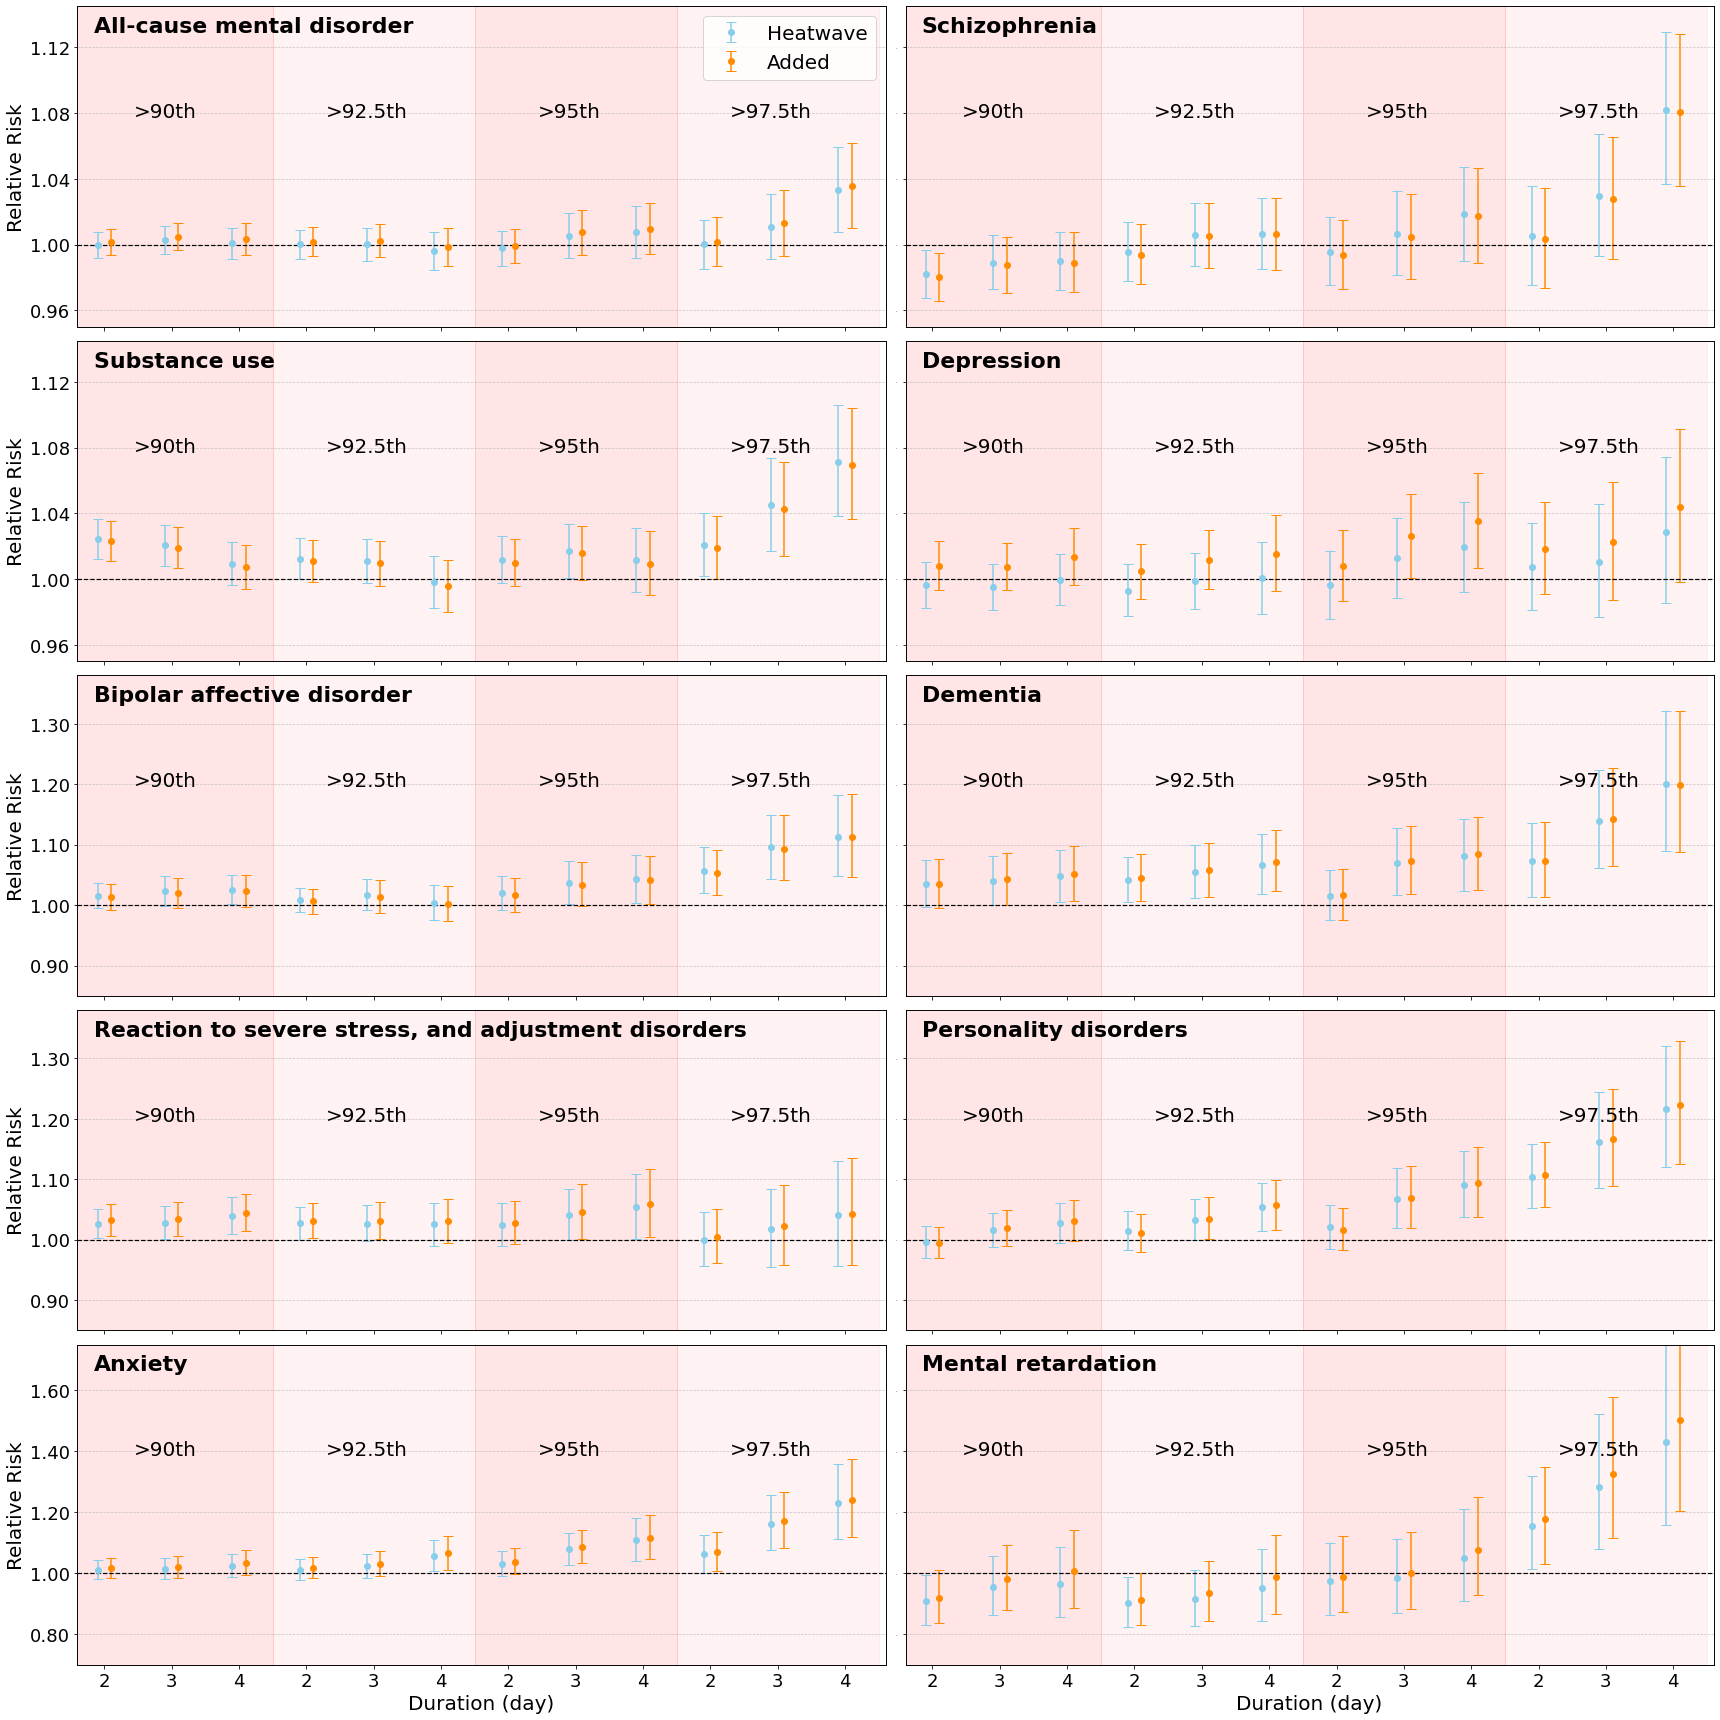

In [13]:
# disease wise sensitivity analysis plots
# 2 * 5 plot, 
fig, axs = plt.subplots(5, 2, figsize=(24, 24))
for index_disease, (disease_code, disease_name) in enumerate(subgroups):
    df_sensitivity_lag0 = df_sensitivity[df_sensitivity['disease'] == disease_code]
    # fig, ax = plt.subplots(figsize=(12, 9))
    ax = axs.flatten()[index_disease]
    # Sort and prepare the data
    df_sensitivity_lag0 = df_sensitivity_lag0.sort_values(by=['threshold', 'duration'])
    df_sensitivity_lag0['cat'] = df_sensitivity_lag0['threshold'].astype(str) + ' ' + df_sensitivity_lag0['duration'].astype(str)
    df_sensitivity_lag0_hw = df_sensitivity_lag0[df_sensitivity_lag0['hw_or_added'] == 'hw'].sort_values(by='cat')
    df_sensitivity_lag0_added = df_sensitivity_lag0[df_sensitivity_lag0['hw_or_added'] == 'added'].sort_values(by='cat')
    # Number of categories
    n = len(df_sensitivity_lag0_hw)
    # Positioning for error bars (centered and closer)
    bar_width = 0.2
    indices = np.arange(n)
    df_sensitivity_lag0_hw['order'] = indices - bar_width / 2
    df_sensitivity_lag0_added['order'] = indices + bar_width / 2
    # Plotting with error bars, adjusted colors for appeal
    ax.errorbar(df_sensitivity_lag0_hw['order'], df_sensitivity_lag0_hw['RR'], 
                yerr=[df_sensitivity_lag0_hw['RR'] - df_sensitivity_lag0_hw['RR_low'], df_sensitivity_lag0_hw['RR_high'] - df_sensitivity_lag0_hw['RR']], 
                fmt='o', color='skyblue',
                label='Heatwave', capsize=5)
    ax.errorbar(df_sensitivity_lag0_added['order'], df_sensitivity_lag0_added['RR'], 
                yerr=[df_sensitivity_lag0_added['RR'] - df_sensitivity_lag0_added['RR_low'], df_sensitivity_lag0_added['RR_high'] - df_sensitivity_lag0_added['RR']], 
                fmt='o', color='darkorange',
                label='Added', capsize=5)
    # Add periodic shading for different thresholds
    unique_thresholds = df_sensitivity_lag0_hw['threshold'].unique()
    for i, threshold in enumerate(unique_thresholds):
        shade_indices = df_sensitivity_lag0_hw[df_sensitivity_lag0_hw['threshold'] == threshold]['order'] + bar_width / 2
        ax.axvspan(shade_indices.min() - 0.5, shade_indices.max() + 0.5, color='red', alpha=0.1 if i % 2 == 0 else 0.05)
   
    ax.set_title(disease_name, fontsize=22, weight='bold', loc='left', y =0.9,x=0.02)
    if index_disease >=8:
        ax.set_xlabel('Duration (day)', fontsize=20)
    if index_disease % 2 ==0:
        ax.set_ylabel('Relative Risk', fontsize=20)


    # Add threshold text in the center of the shaded area under the duration x-label
    for i, threshold in enumerate(unique_thresholds):
        shade_indices = df_sensitivity_lag0_hw[df_sensitivity_lag0_hw['threshold'] == threshold]['order']
        mid_point = (shade_indices.min() + shade_indices.max()) / 2
        if i % 2 == 0:
            ax.text(mid_point, 0.7, 
                    ">" + str(int(threshold)) + 'th',
                    ha='center', va='top', fontsize=20, transform=ax.get_xaxis_transform())
        else:
            ax.text(mid_point, 0.7, 
                ">" + str(threshold) + 'th',
                ha='center', va='top', fontsize=20, transform=ax.get_xaxis_transform())
    # Hide the secondary x-axis
    ax2 = ax.twiny()
    ax2.set_xticks([])  # Remove ticks on the secondary axis
    ax2.set_xticklabels([])  # Remove labels on the secondary axis

    # Legend and grid settings
    if index_disease == 0:
        ax.legend(fontsize=20)
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.set_xlim(-bar_width*2, n - 2*bar_width)  # Adjust the x-axis limits for better visibility
    ax.set_ylim(0.95, 1.15)  # Adjust the y-axis limits for better visibility
    #add y = 1 line
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2)
    # Adjust the layout to fit all elements
    # Set x-ticks for duration
    ax.set_xticks(indices)
    if index_disease >= 8:
        ax.set_xticklabels(df_sensitivity_lag0_hw['duration'],  ha='center', fontsize=18)
    else:
        ax.set_xticklabels([],  ha='center', fontsize=18)
        
    if index_disease <4:
        ticks = [0.96, 1.00, 1.04, 1.08,1.12]
        labels = ['0.96', '1.00', '1.04', '1.08', '1.12']
        ax.set_ylim(0.95, 1.145)  # Adjust the y-axis limits for better visibility

    # elseif index_disease < 8:
    elif index_disease <8:
            ticks = [0.9, 1.0, 1.1,1.2,1.3]
            labels = ['0.90', '1.00', '1.10', '1.20', '1.30']
            ax.set_ylim(0.85, 1.38) 
    else:
        ticks = [0.8, 1.0,  1.2,1.4,1.6]
        labels = ['0.80', '1.00',  '1.20', '1.40', '1.60']
        ax.set_ylim(0.7, 1.75) 

    ax.set_yticks(ticks)
    ax.set_yticklabels(labels, fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    if index_disease % 2 ==1:
        # remove y tick labels
        ax.tick_params(axis='y', labelsize=False)
# export the figure as pdf and png called Figure_S8
plt.savefig(figure_base_dir + 'Figure_S8.pdf', dpi=600, bbox_inches='tight')
plt.savefig(figure_base_dir + 'Figure_S8.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [14]:
# country-wise sensitivity analysis plots
country_list = ['Brazil', 'Canada', 'Chile', 'New_Zealand']
df_sensitivity = df.copy()
df_sensitivity = df_sensitivity.drop(columns=["Unnamed: 0"])
df_sensitivity = df_sensitivity.drop_duplicates()
df_sensitivity = df_sensitivity[df_sensitivity['lag'] == 0]
df_sensitivity = df_sensitivity[df_sensitivity['disease'] == 'all']
df_sensitivity = df_sensitivity[df_sensitivity['category'] == 'country']

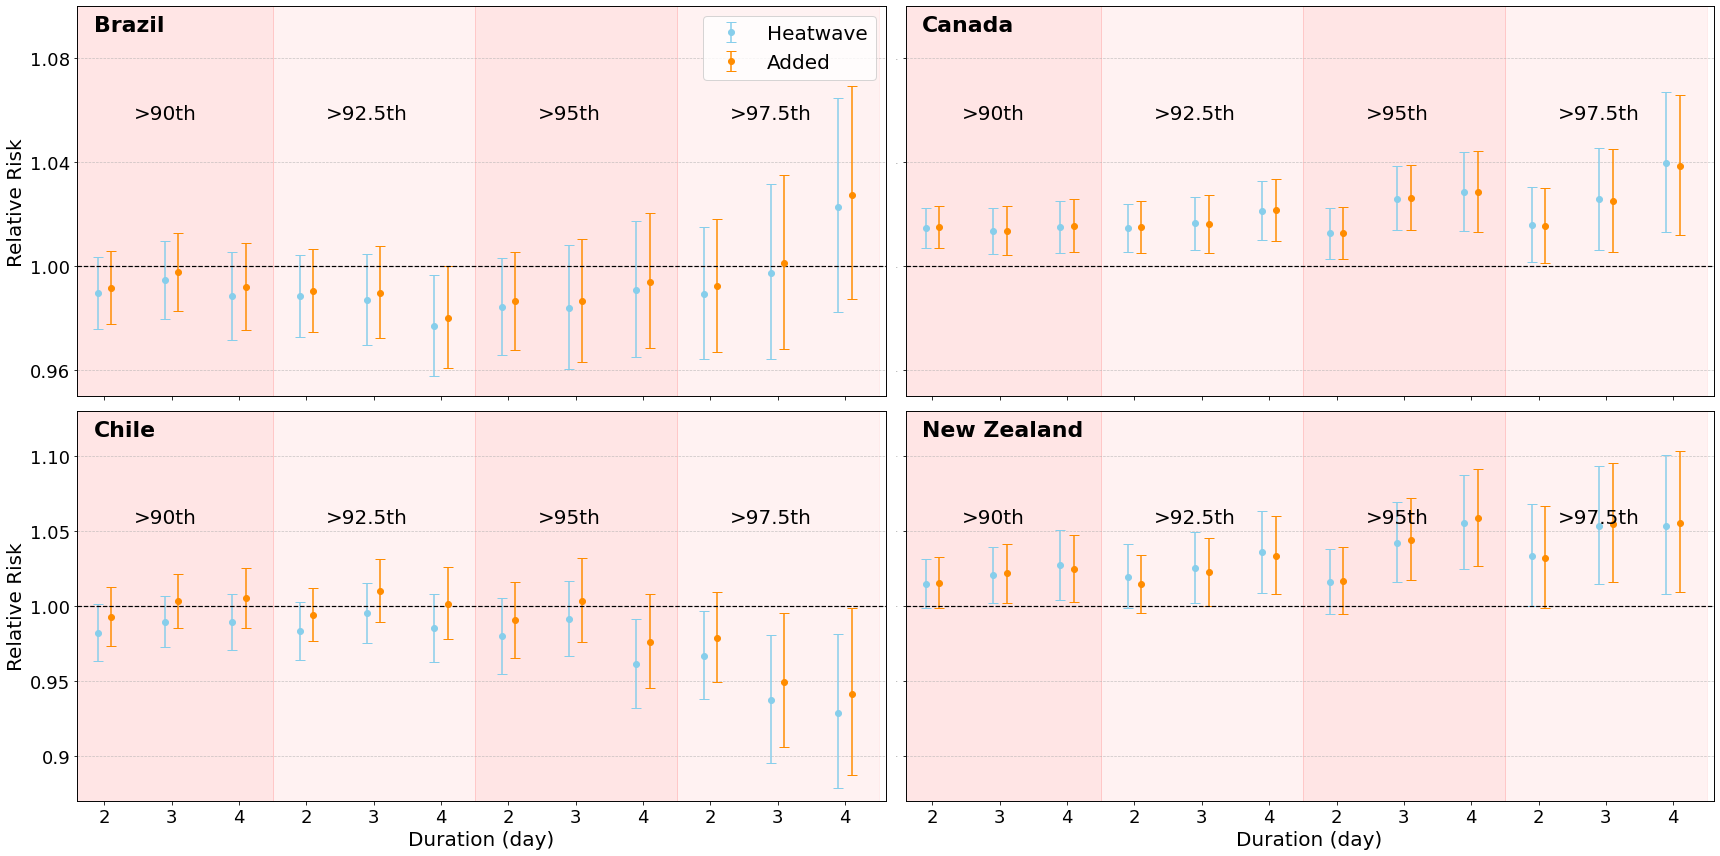

In [17]:

fig, axs = plt.subplots(2, 2, figsize=(24, 12))
for index_sub, sub in enumerate(country_list):
    df_sensitivity_lag0 = df_sensitivity[df_sensitivity['subgroup'] == sub]
    # fig, ax = plt.subplots(figsize=(12, 9))
    ax = axs.flatten()[index_sub]
    # Sort and prepare the data
    df_sensitivity_lag0 = df_sensitivity_lag0.sort_values(by=['threshold', 'duration'])
    df_sensitivity_lag0['cat'] = df_sensitivity_lag0['threshold'].astype(str) + ' ' + df_sensitivity_lag0['duration'].astype(str)
    df_sensitivity_lag0_hw = df_sensitivity_lag0[df_sensitivity_lag0['hw_or_added'] == 'hw'].sort_values(by='cat')
    df_sensitivity_lag0_added = df_sensitivity_lag0[df_sensitivity_lag0['hw_or_added'] == 'added'].sort_values(by='cat')
    # Number of categories
    n = len(df_sensitivity_lag0_hw)
    # Positioning for error bars (centered and closer)
    bar_width = 0.2
    indices = np.arange(n)
    df_sensitivity_lag0_hw['order'] = indices - bar_width / 2
    df_sensitivity_lag0_added['order'] = indices + bar_width / 2
    # Plotting with error bars, adjusted colors for appeal
    ax.errorbar(df_sensitivity_lag0_hw['order'], df_sensitivity_lag0_hw['RR'], 
                yerr=[df_sensitivity_lag0_hw['RR'] - df_sensitivity_lag0_hw['RR_low'], df_sensitivity_lag0_hw['RR_high'] - df_sensitivity_lag0_hw['RR']], 
                fmt='o', color='skyblue',
                label='Heatwave', capsize=5)
    ax.errorbar(df_sensitivity_lag0_added['order'], df_sensitivity_lag0_added['RR'], 
                yerr=[df_sensitivity_lag0_added['RR'] - df_sensitivity_lag0_added['RR_low'], df_sensitivity_lag0_added['RR_high'] - df_sensitivity_lag0_added['RR']], 
                fmt='o', color='darkorange',
                label='Added', capsize=5)
    # Add periodic shading for different thresholds
    unique_thresholds = df_sensitivity_lag0_hw['threshold'].unique()
    for i, threshold in enumerate(unique_thresholds):
        shade_indices = df_sensitivity_lag0_hw[df_sensitivity_lag0_hw['threshold'] == threshold]['order'] + bar_width / 2
        ax.axvspan(shade_indices.min() - 0.5, shade_indices.max() + 0.5, color='red', alpha=0.1 if i % 2 == 0 else 0.05)
    # Title and labels with improved formatting
    # ax.set_title('Sensitivity Analysis', fontsize=18, weight='bold', loc='left')
    # ax.set_xlabel('Duration (day)', fontsize=20)
    # ax.set_ylabel('Relative Risk', fontsize=20)
    # ax.set_title(f'Subgroup: {sub}', fontsize=22, weight='bold', loc='left')
    if sub == "New_Zealand":
        ax.set_title('New Zealand', fontsize=22, weight='bold', loc='left', y =0.92,x=0.02)
    else:
        ax.set_title(sub, fontsize=22, weight='bold', loc='left', y =0.92,x=0.02)
        
    if index_sub >=2:
        ax.set_xlabel('Duration (day)', fontsize=20)
    if index_sub ==0 or index_sub ==2:
        ax.set_ylabel('Relative Risk', fontsize=20)


    # Add threshold text in the center of the shaded area under the duration x-label
    for i, threshold in enumerate(unique_thresholds):
        shade_indices = df_sensitivity_lag0_hw[df_sensitivity_lag0_hw['threshold'] == threshold]['order']
        mid_point = (shade_indices.min() + shade_indices.max()) / 2
        if i % 2 == 0:
            ax.text(mid_point, 0.75, 
                    ">" + str(int(threshold)) + 'th',
                    ha='center', va='top', fontsize=20, transform=ax.get_xaxis_transform())
        else:
            ax.text(mid_point, 0.75, 
                ">" + str(threshold) + 'th',
                ha='center', va='top', fontsize=20, transform=ax.get_xaxis_transform())
    # Hide the secondary x-axis
    ax2 = ax.twiny()
    ax2.set_xticks([])  # Remove ticks on the secondary axis
    ax2.set_xticklabels([])  # Remove labels on the secondary axis

    # Legend and grid settings
    if index_sub == 0:
        ax.legend(fontsize=20)
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.set_xlim(-bar_width*2, n - 2*bar_width)  # Adjust the x-axis limits for better visibility
    #add y = 1 line
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2)
    # Adjust the layout to fit all elements
    # Set x-ticks for duration
    ax.set_xticks(indices)
    if index_sub >= 2:
        ax.set_xticklabels(df_sensitivity_lag0_hw['duration'],  ha='center', fontsize=18)
    else:
        ax.set_xticklabels([],  ha='center', fontsize=18)
        
    if index_sub < 2:
        ticks = [0.96, 1.00, 1.04, 1.08]
        labels = ['0.96', '1.00', '1.04', '1.08']
        ax.set_ylim(0.95, 1.1)  # Adjust the y-axis limits for better visibility


    else:
        ticks = [0.9, 0.95, 1.00, 1.05,1.1]
        labels = ['0.9', '0.95', '1.00', '1.05', '1.10']
        ax.set_ylim(0.87, 1.13)  # Adjust the y-axis limits for better visibility

    ax.set_yticks(ticks)

    if index_sub % 2 ==0:
        ax.set_yticklabels(labels, fontsize=18)
        ax.tick_params(axis='y', labelsize=18)
    else:
        # remove y tick labels
        ax.tick_params(axis='y', labelsize=False)

# export the figure as pdf and png called Figure_S7
plt.savefig(figure_base_dir + 'Figure_S7.pdf', dpi=600, bbox_inches='tight')
plt.savefig(figure_base_dir + 'Figure_S7.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [18]:
# country-wise sensitivity analysis plots
df_sensitivity = df.copy()
df_sensitivity = df_sensitivity.drop(columns=["Unnamed: 0"])
df_sensitivity = df_sensitivity.drop_duplicates()
df_sensitivity = df_sensitivity[df_sensitivity['lag'] == 0]
df_sensitivity = df_sensitivity[df_sensitivity['disease'] == 'all']
sub_category_order = {
    'GDP': ['low', 'high'],
    'pop_density': ['low', 'high'],
    'ac_penetration': ['low', 'high'],
    'travel_time_healthcare': ['low', 'high']
}


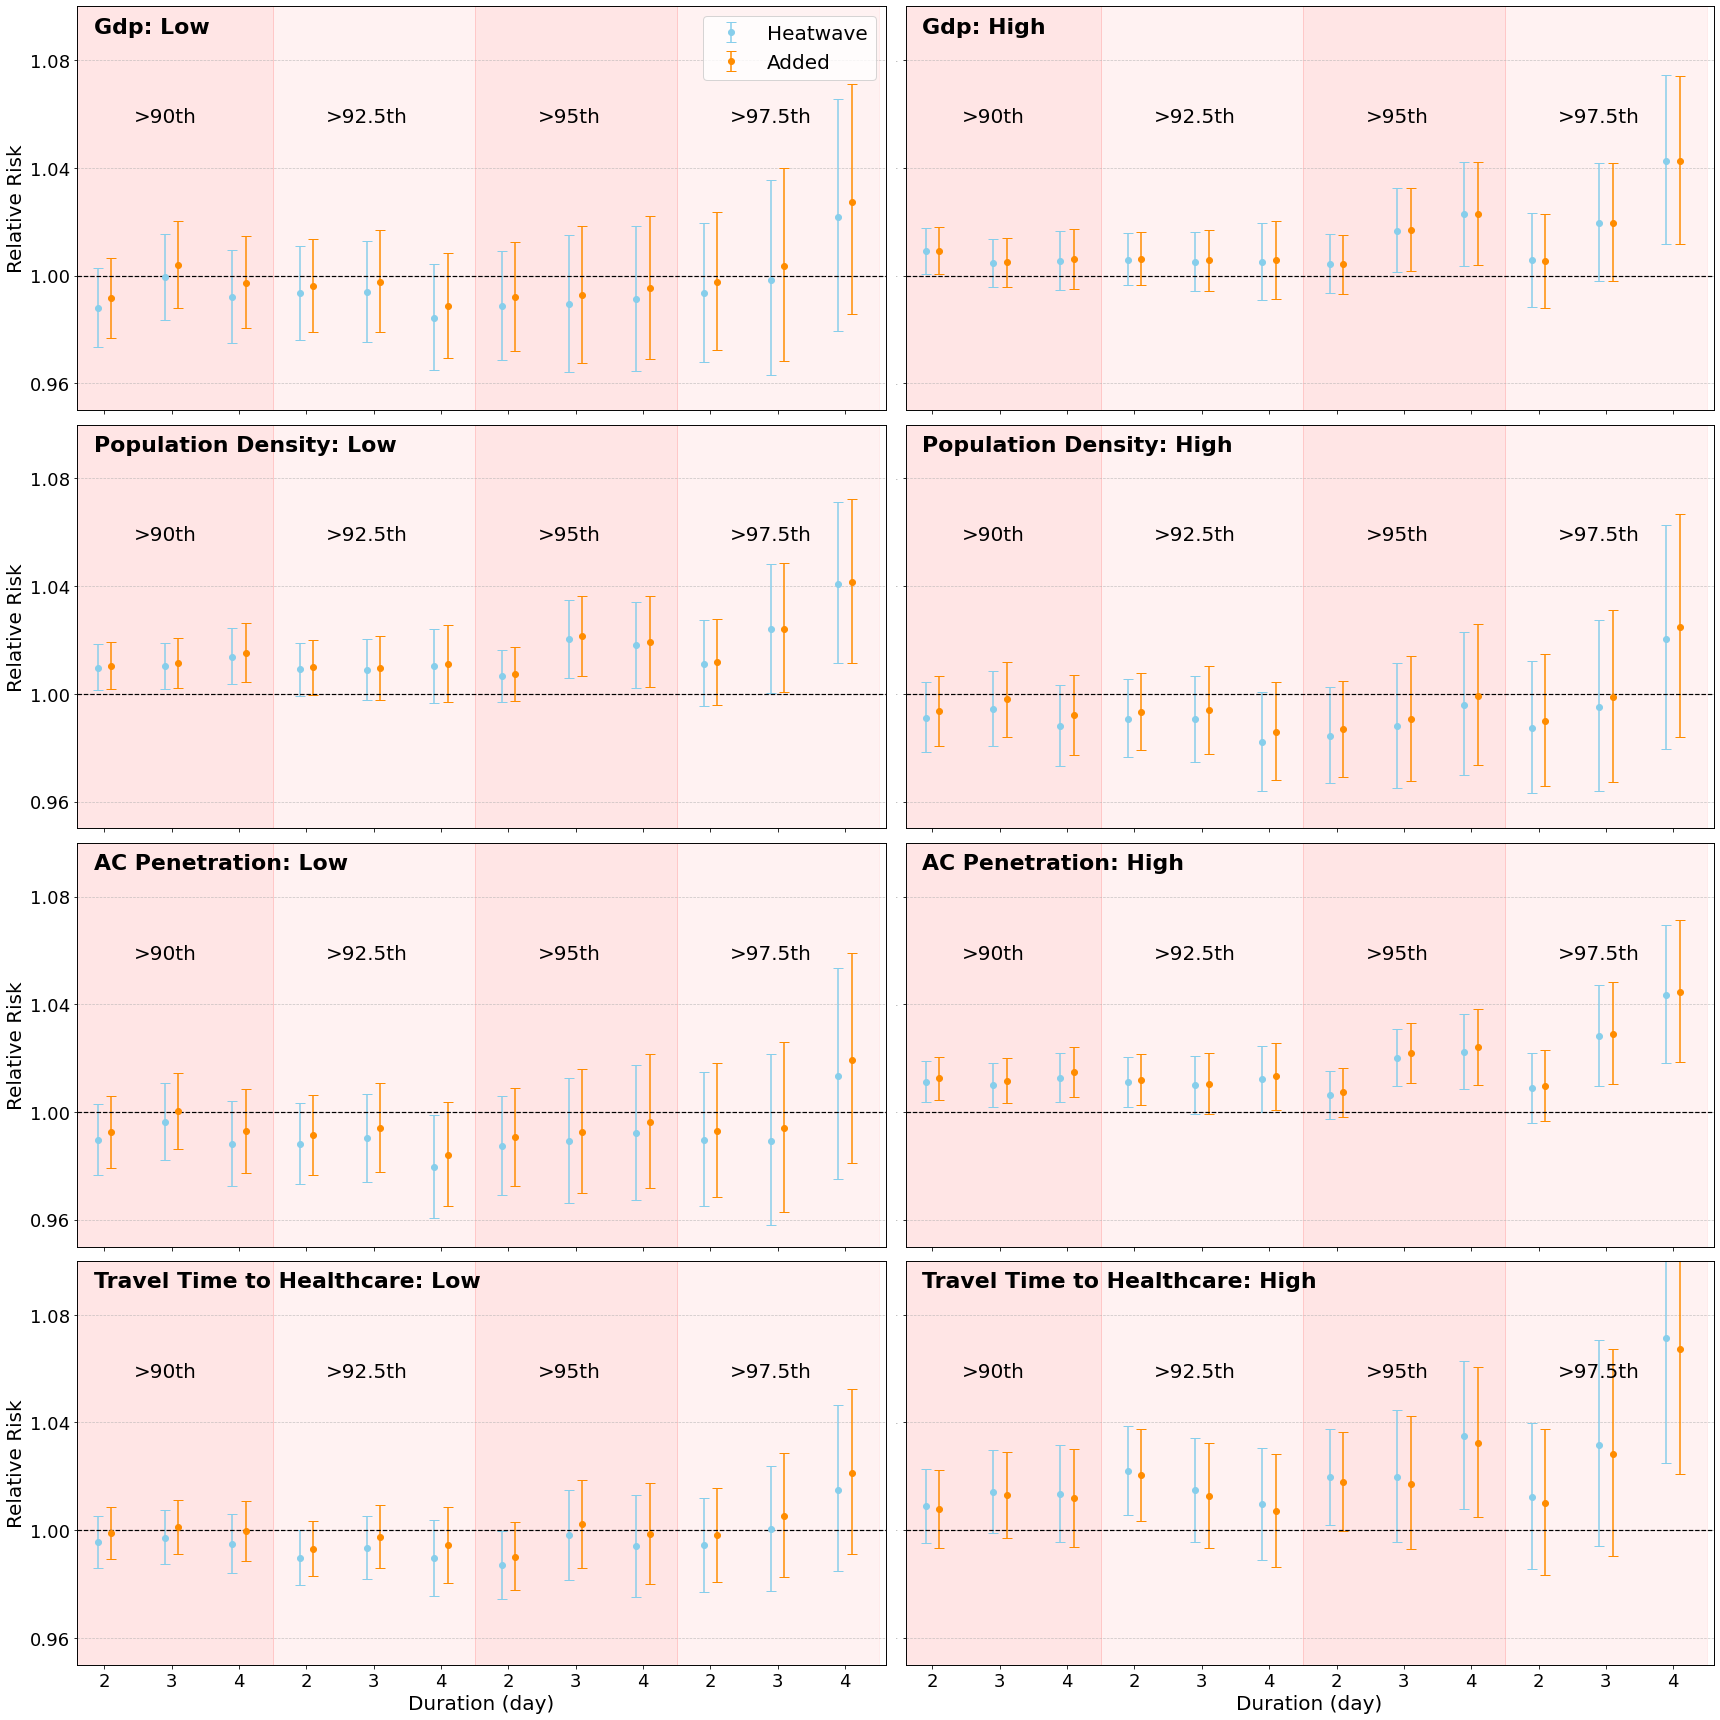

In [20]:
fig, axs = plt.subplots(4, 2, figsize=(24, 24))
gov_index = 0
for index_sub, (category, subcats) in enumerate(sub_category_order.items()):
    for index_subcat, sub in enumerate(subcats):
        df_sensitivity_lag0 = df_sensitivity[(df_sensitivity['category'] == category) & (df_sensitivity['subgroup'] == sub)]
        # fig, ax = plt.subplots(figsize=(12, 9))
        ax = axs.flatten()[gov_index]
        # Sort and prepare the data
        df_sensitivity_lag0 = df_sensitivity_lag0.sort_values(by=['threshold', 'duration'])
        df_sensitivity_lag0['cat'] = df_sensitivity_lag0['threshold'].astype(str) + ' ' + df_sensitivity_lag0['duration'].astype(str)
        df_sensitivity_lag0_hw = df_sensitivity_lag0[df_sensitivity_lag0['hw_or_added'] == 'hw'].sort_values(by='cat')
        df_sensitivity_lag0_added = df_sensitivity_lag0[df_sensitivity_lag0['hw_or_added'] == 'added'].sort_values(by='cat')
        # Number of categories
        n = len(df_sensitivity_lag0_hw)
        # Positioning for error bars (centered and closer)
        bar_width = 0.2
        indices = np.arange(n)
        df_sensitivity_lag0_hw['order'] = indices - bar_width / 2
        df_sensitivity_lag0_added['order'] = indices + bar_width / 2
        # Plotting with error bars, adjusted colors for appeal
        ax.errorbar(df_sensitivity_lag0_hw['order'], df_sensitivity_lag0_hw['RR'], 
                    yerr=[df_sensitivity_lag0_hw['RR'] - df_sensitivity_lag0_hw['RR_low'], df_sensitivity_lag0_hw['RR_high'] - df_sensitivity_lag0_hw['RR']], 
                    fmt='o', color='skyblue',
                    label='Heatwave', capsize=5)
        ax.errorbar(df_sensitivity_lag0_added['order'], df_sensitivity_lag0_added['RR'], 
                    yerr=[df_sensitivity_lag0_added['RR'] - df_sensitivity_lag0_added['RR_low'], df_sensitivity_lag0_added['RR_high'] - df_sensitivity_lag0_added['RR']], 
                    fmt='o', color='darkorange',
                    label='Added', capsize=5)
        # Add periodic shading for different thresholds
        unique_thresholds = df_sensitivity_lag0_hw['threshold'].unique()
        for i, threshold in enumerate(unique_thresholds):
            shade_indices = df_sensitivity_lag0_hw[df_sensitivity_lag0_hw['threshold'] == threshold]['order'] + bar_width / 2
            ax.axvspan(shade_indices.min() - 0.5, shade_indices.max() + 0.5, color='red', alpha=0.1 if i % 2 == 0 else 0.05)
        if sub == 'low':
            sub_name = 'Low '
        else:
            sub_name = 'High '
        if category == 'pop_density':
            category_name = 'Population Density'
        elif category == 'ac_penetration':
            category_name = 'AC Penetration'
        elif category == 'travel_time_healthcare':
            category_name = 'Travel Time to Healthcare'
        else:
            category_name = category.capitalize()
        ax.set_title(category_name + ": " + sub_name, fontsize=22, weight='bold', loc='left', y =0.92,x=0.02)

        if gov_index >=6:
            ax.set_xlabel('Duration (day)', fontsize=20)
        if gov_index ==0 or gov_index ==2 or gov_index ==4 or gov_index ==6:
            ax.set_ylabel('Relative Risk', fontsize=20)


        # Add threshold text in the center of the shaded area under the duration x-label
        for i, threshold in enumerate(unique_thresholds):
            shade_indices = df_sensitivity_lag0_hw[df_sensitivity_lag0_hw['threshold'] == threshold]['order']
            mid_point = (shade_indices.min() + shade_indices.max()) / 2
            if i % 2 == 0:
                ax.text(mid_point, 0.75, 
                        ">" + str(int(threshold)) + 'th',
                        ha='center', va='top', fontsize=20, transform=ax.get_xaxis_transform())
            else:
                ax.text(mid_point, 0.75, 
                    ">" + str(threshold) + 'th',
                    ha='center', va='top', fontsize=20, transform=ax.get_xaxis_transform())
        # Hide the secondary x-axis
        ax2 = ax.twiny()
        ax2.set_xticks([])  # Remove ticks on the secondary axis
        ax2.set_xticklabels([])  # Remove labels on the secondary axis

        # Legend and grid settings
        if gov_index == 0:
            ax.legend(fontsize=20)
        ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
        ax.set_xlim(-bar_width*2, n - 2*bar_width)  # Adjust the x-axis limits for better visibility
        #add y = 1 line
        ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2)
        # Adjust the layout to fit all elements
        # Set x-ticks for duration
        ax.set_xticks(indices)
        if gov_index >= 6:
            ax.set_xticklabels(df_sensitivity_lag0_hw['duration'],  ha='center', fontsize=18)
        else:
            ax.set_xticklabels([],  ha='center', fontsize=18)
            
        ticks = [0.96, 1.00, 1.04, 1.08]
        labels = ['0.96', '1.00', '1.04', '1.08']
        ax.set_ylim(0.95, 1.1)  # Adjust the y-axis limits for better visibility
     
        ax.set_yticks(ticks)

        if gov_index % 2 ==0:
            ax.set_yticklabels(labels, fontsize=18)
            ax.tick_params(axis='y', labelsize=18)
        else:
            # remove y tick labels
            ax.tick_params(axis='y', labelsize=False)
        gov_index +=1

# export the figure as pdf and png called Figure_S9
plt.savefig(figure_base_dir + 'Figure_S9.pdf', dpi=600, bbox_inches='tight')
plt.savefig(figure_base_dir + 'Figure_S9.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [21]:
df_sensitivity = df.copy()
df_sensitivity = df_sensitivity.drop(columns=["Unnamed: 0"])
df_sensitivity = df_sensitivity.drop_duplicates()
df_sensitivity = df_sensitivity[df_sensitivity['lag'] == 0]
df_sensitivity = df_sensitivity[df_sensitivity['threshold'] == 97.5]
df_sensitivity = df_sensitivity[df_sensitivity['duration'] == 4]
df_hw = df_sensitivity[df_sensitivity['hw_or_added'] == 'hw']

In [ ]:
# get unique categories
category_list = df_sensitivity['category'].unique().tolist()

['all', 'GDP', 'RDI', 'pop_density', 'climate', 'travel_time_healthcare', 'ac_penetration', 'country', 'sex', 'age']


In [23]:
subgroups = [
    ("all", "All-cause mental disorder"),
    ("SCHZ", "Schizophrenia"),
    ("SUB", "Substance use"),
    ("DEP", "Depression"),
    ("BPAD", "Bipolar affective disorder"),
    ("DEM", "Dementia"),
    ("RSAD", "Reaction to severe stress, and adjustment disorders"),
    ("PD", "Personality disorders"),
    ("ANX", "Anxiety"),
    ("MR", "Mental retardation")
]


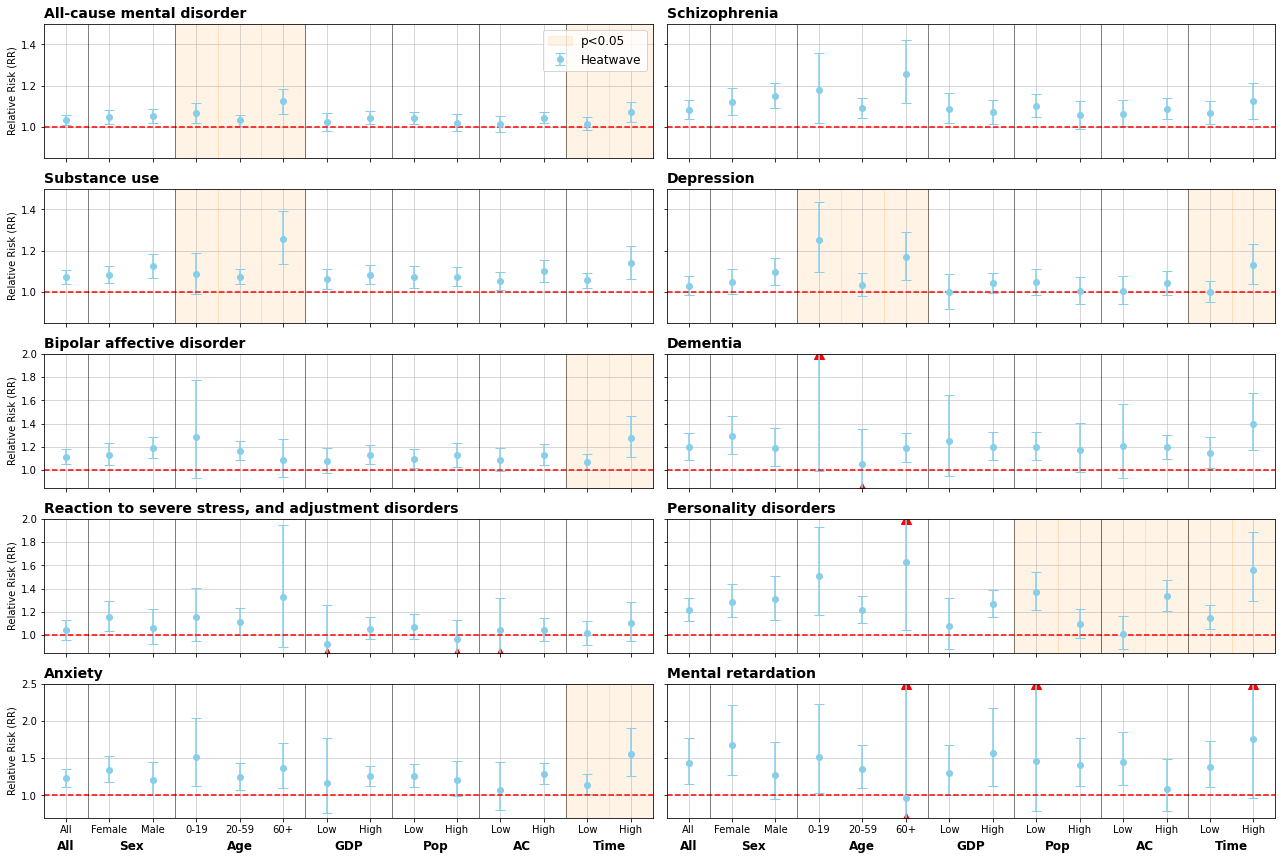

In [36]:
# Set the y-limits across all figures
ymin, ymax = 0.85, 1.5  # Adjust these values based on your data

# Given lists and dictionaries
category_order = ['all', 'sex', 'age', 'GDP', 'pop_density','ac_penetration','travel_time_healthcare']
sub_category_order = {
    'all': ['all'],
    'sex': ['female', 'male'],
    'age': ['0-19', '20-59', '60+'],
    'GDP': ['low', 'high'],
    'pop_density': ['low', 'high'],
    'ac_penetration': ['low', 'high'],
    'travel_time_healthcare': ['low', 'high']
}

fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(18, 12))
axs = axs.flatten()  # Flatten the 2D array of axes into a 1D array for easier indexing

for i, (disease, disease_name) in enumerate(subgroups):
    if i > 3:
        ymin, ymax = 0.85, 2
    if i > 7:
        ymin, ymax = 0.7, 2.5
    df_hw_tem = df_hw[df_hw["disease"] == disease]
    df_hw_reorder = pd.DataFrame()
    df_added_reorder = pd.DataFrame()
    
    # Reorganize the df based on the subcategory
    for category in category_order:
        sub_category_list = sub_category_order.get(category, [])
        df_hw_sub = df_hw_tem[df_hw_tem['category'] == category]
        for sub_category in sub_category_list:
            df_hw_sub_sub = df_hw_sub[df_hw_sub['subgroup'] == sub_category]
            df_hw_reorder = pd.concat([df_hw_reorder, df_hw_sub_sub])
    
    df_hw_reorder['ind'] = range(len(df_hw_reorder))
    df_hw_reorder['subgroup_name'] = df_hw_reorder['subgroup'].apply(lambda x: x.capitalize())
    # Data for plotting
    x_hw = df_hw_reorder["ind"].values
    y_hw = df_hw_reorder["RR"].values
    y_up = df_hw_reorder["RR_high"].values
    y_btm = df_hw_reorder["RR_low"].values
    p_hw = df_hw_reorder["P_value"].values

    # Clip the error bars if they exceed the y-limits
    y_up_clipped = np.clip(y_up, ymin, ymax)
    y_btm_clipped = np.clip(y_btm, ymin, ymax)

    # Plot error bars with clipping
    axs[i].errorbar(x_hw, y_hw, yerr=[y_hw - y_btm, y_up - y_hw], 
                    fmt='o', color="skyblue", capsize=5, label="Heatwave")

    # Mark points outside y-limits with caret '^' markers
    for j in range(len(x_hw)):
        if y_up[j] > ymax:
            axs[i].scatter(x_hw[j], y_up_clipped[j], marker='^', color='red', s=100)
        if y_btm[j] < ymin:
            axs[i].scatter(x_hw[j], y_btm_clipped[j], marker='^', color='red', s=100)
        # if y_up[j] > ymax or y_btm[j] < ymin:
        #     axs[i].plot(x_hw[j], y_hw_clipped[j], marker='^', color='red', markersize=8)

    # Draw y=1 line
    axs[i].axhline(y=1, color='red', linestyle='--')
    axs[i].set_xlim(-1, len(df_hw_reorder))
    axs[i].set_xticks(df_hw_reorder["ind"].values)
    axs[i].set_xticklabels(df_hw_reorder["subgroup_name"].values)
    axs[i].set_ylim(ymin, ymax)  # Fix the y-limits
    axs[i].set_title(disease_name, fontsize=14, weight='bold', loc='left')
    # axs[i].legend()
    axs[i].grid(True, linewidth=0.5)

    x_pos_shade = [0.5, 2.5, 5.5, 7.5, 9.5, 11.5,14.5, 16.5]
    x_pos_text = [0, 1.5, 4, 6.5, 8.5, 10.5, 12.5]
    
    # Add shade for each category and add the category name based on x_pos_shade and x_pos_text
    for j in range(len(x_pos_shade)):
        axs[i].axvline(x=x_pos_shade[j], color='black', linestyle='-', linewidth=0.5)
    
    # Add category names to the shaded areas
    for j in range(len(p_hw)):
        if p_hw[j] < 0.05:
            axs[i].axvspan(x_hw[j] - 0.5, x_hw[j] + 0.5, color='darkorange', alpha=0.1)

    if i < 8:
        axs[i].set_xticks(range(0, 14, 1))
        axs[i].set_xticklabels([])
    else:
        axs[i].set_xticks(range(0, 14, 1))
        for j, category in enumerate(category_order):
            if j < len(x_pos_text):
                if category == 'all':
                    category = 'All'
                if category == 'sex':
                    category = 'Sex'
                if category == 'age':
                    category = 'Age'
                if category == 'ac_penetration':
                    category = 'AC'
                if category == 'travel_time_healthcare':
                    category = 'Time'
                if category == 'pop_density':
                    category = 'Pop'
                axs[i].text(x_pos_text[j], ymax - 2.1, category, ha='center', va='top', fontsize=12, weight='bold')
    
    # Add legend for p-value
    if i ==0:
        axs[i].axvspan(-1, -1, color='darkorange', alpha=0.1, label='p<0.05')
        axs[i].legend(loc='upper right', fontsize=12)
    
    if i in [0, 2, 4, 6, 8, 10]:
        axs[i].set_ylabel("Relative Risk (RR)", fontsize=10)
    else:
        axs[i].set_yticklabels([])

    axs[i].set_xlim(-0.5, 13.5)
# Adjust layout and display the plot
# export the figure as pdf and png called Figure_3
plt.savefig(figure_base_dir + 'Figure_3.pdf', dpi=600, bbox_inches='tight')
plt.savefig(figure_base_dir + 'Figure_3.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [ ]:
df_afan_dir = 'cases_summary.csv'
df_afan = pd.read_csv(df_afan_dir)
df_rr_dir = 'revision_rr_sum_975_4.csv'
df_rr = pd.read_csv(df_rr_dir)

In [ ]:
df_rr = df_rr[df_rr['hw_or_added'] == 'hw']
df_rr = df_rr[df_rr['lag'] == 0]
# only keep disease, category, subgroup, RR, RR_low, RR_high
df_rr = df_rr[['disease', 'category', 'subgroup', 'RR', 'RR_low', 'RR_high']]
# merge df_afan and df_rr on disease, category

In [ ]:
# change column name of df_rr
df_rr = df_rr.rename(columns={'category': 'main_group', 'subgroup': 'sub_group'})
#['GDP' 'ac_penetration' 'age' 'all' 'country' 'pop' 'sex' 'walking_time'] if names are different, drop the rest

# keep only rows with main_group in ['all' 'GDP' 'pop_density'  'travel_time_healthcare' 'ac_penetration' 'country' 'sex' 'age']
df_rr = df_rr[df_rr['main_group'].isin(['all', 'GDP', 'pop_density', 'travel_time_healthcare', 'ac_penetration', 'country', 'sex', 'age'])]
# replace main_group names
main_group_rename = {
    'all': 'all',
    'GDP': 'GDP',
    'pop_density': 'pop',
    'travel_time_healthcare': 'walking_time',
    'ac_penetration': 'ac_penetration',
    'country': 'country',
    'sex': 'sex',
    'age': 'age'
}
df_rr['main_group'] = df_rr['main_group'].replace(main_group_rename)
df_afan = df_afan.merge(df_rr, left_on=['disease', 'main_group', 'sub_group'], right_on=['disease', 'main_group', 'sub_group'], how='left')


In [ ]:
df_afan.head()

In [ ]:
# use three decimal places for RR, RR_low, RR_high
df_afan['RR'] = df_afan['RR'].round(3)
df_afan['RR_low'] = df_afan['RR_low'].round(3)
df_afan['RR_high'] = df_afan['RR_high'].round(3)
df_afan['AF'] = (df_afan['RR'] - 1) / df_afan['RR']
df_afan['AF_low'] = (df_afan['RR_low'] - 1) / df_afan['RR_low']
df_afan['AF_high'] = (df_afan['RR_high'] - 1) / df_afan['RR_high']
# calculate AF cases
df_afan['AN'] = df_afan['AF'] * df_afan['heatwave_affected_cases']
df_afan['AN_low'] = df_afan['AF_low'] * df_afan['heatwave_affected_cases']
df_afan['AN_high'] = df_afan['AF_high'] * df_afan['heatwave_affected_cases']

df_afan['AN_rd'] = df_afan['AF'] * df_afan['re_distributed_cases']
df_afan['AN_rd_low'] = df_afan['AF_low'] * df_afan['re_distributed_cases']
df_afan['AN_rd_high'] = df_afan['AF_high'] * df_afan['re_distributed_cases']

In [ ]:
df_afan.to_csv('cases.csv', index=False)

# Table preparation

In [ ]:
diseases = ['all','SCHZ','SUB','DEP','BPAD','DEM','RSAD','PD','ANX','MR','BED','DCD',
            'MAN','DPD','PMD','SFD','OCD','UMD','OMD','OND']
dis_lut = [
    ("all", "All-cause mental disorder"),
    ("SCHZ", "Schizophrenia"),
    ("SUB", "Substance use"),
    ("DEP", "Depression"),
    ("BPAD", "Bipolar affective disorder"),
    ("DEM", "Dementia"),
    ("RSAD", "Reaction to severe stress, and adjustment disorders"),
    ("PD", "Personality disorders"),
    ("ANX", "Anxiety"),
    ("MR", "Mental retardation")
]
# Table skeleton
row_names = ["All",
        "Sex",
        "  Female", "  Male",
        "Age, years",
        "  0-19", "  20-59", "  60+",
        "Country",
        "  Brazil", "  Canada", "  Chile", "  New Zealand",
        "GDP",
        "  Low", "  High",
        "Population density",
        "  Low", "  High",
        "AC penetration",
        "  Low", "  High",
        "Walking distance",
        "  Low", "  High"
]

rows = ["All",
        "Sex",
        "  Female", "  Male",
        "Age, years",
        "  0-19", "  20-59", "  60+",
        "Country",
        "  Brazil", "  Canada", "  Chile", "  New Zealand",
        "GDP",
        "  Low (GDP)", "  High (GDP)",
        "Population density",
        "  Low (Pop)", "  High (Pop)",
        "AC penetration",
        "  Low (AC)", "  High (AC)",
        "Walking distance",
        "  Low (Walk)", "  High (Walk)"
]

row_lut = {
    "All": ("all", "all"),
    "Sex": (None, None),
    "  Female": ("sex", "female"),
    "  Male": ("sex", "male"),
    "Age, years": (None, None),
    "  0-19": ("age", "0-19"),
    "  20-59": ("age", "20-59"),
    "  60+": ("age", "60+"),
    "Country": (None, None),
    "  Brazil": ("country", "Brazil"),
    "  Canada": ("country", "Canada"),
    "  Chile": ("country", "Chile"),
    "  New Zealand": ("country", "New_Zealand"),

    "GDP": (None, None),
    "  Low (GDP)": ("GDP", "low"),
    "  High (GDP)": ("GDP", "high"),

    "Population density": (None, None),
    "  Low (Pop)": ("pop", "low"),
    "  High (Pop)": ("pop", "high"),

    "AC penetration": (None, None),
    "  Low (AC)": ("ac_penetration", "low"),
    "  High (AC)": ("ac_penetration", "high"),

    "Walking distance": (None, None),
    "  Low (Walk)": ("walking_time", "low"),
    "  High (Walk)": ("walking_time", "high"),
}


In [ ]:
# create a new dataframe for the table with disease being columns and rows being the rows list above, and values being the AN_rd value in df_afan based on the row_lut
table_df = pd.DataFrame(index=rows, columns=diseases)
column_of_interest = 'total_cases'
total_case = df_afan[df_afan['main_group'] == 'all'][df_afan['sub_group'] == 'all'][df_afan['disease'] == 'all'][column_of_interest].values[0]
for row in rows:
    main_group, sub_group = row_lut[row]
    for disease in diseases:
        if main_group is None and sub_group is None:
            value = []
        else:
            value = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][column_of_interest].values
            if len(value) > 0:
                v = value[0]
                p = v / total_case
                p = round(p * 100, 2)
                v = int(round(v))
                # make the value in the format of "v (p%) in two lines, with v in the first line and p% in the second line
                table_df.loc[row, disease] = f"{v} \n({p}%)"
            else:
                table_df.loc[row, disease] = str("NA")
# overwrite the line index with the row_names
table_df.index = row_names
table_df.to_csv('cases_table.csv')

In [ ]:
# create a new dataframe for the table with disease being columns and rows being the rows list above, and values being the AN_rd value in df_afan based on the row_lut
table_df = pd.DataFrame(index=rows, columns=diseases)
column_of_interest = 'uncorrected_cases'
total_case = df_afan[df_afan['main_group'] == 'all'][df_afan['sub_group'] == 'all'][df_afan['disease'] == 'all'][column_of_interest].values[0]
for row in rows:
    main_group, sub_group = row_lut[row]
    for disease in diseases:
        if main_group is None and sub_group is None:
            value = []
        else:
            value = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][column_of_interest].values
            if len(value) > 0:
                v = value[0]
                p = v / total_case
                p = round(p * 100, 2)
                v = int(round(v))
                # make the value in the format of "v (p%) in two lines, with v in the first line and p% in the second line
                table_df.loc[row, disease] = f"{v} \n({p}%)"
            else:
                table_df.loc[row, disease] = str("NA")
# overwrite the line index with the row_names
table_df.index = row_names
table_df.to_csv('cases_table_uncorrected.csv')

In [ ]:
# create a new dataframe for the table with disease being columns and rows being the rows list above, and values being the AN_rd value in df_afan based on the row_lut
table_df = pd.DataFrame(index=rows, columns=diseases)
column_of_interest = 'heatwave_affected_cases'
total_case = df_afan[df_afan['main_group'] == 'all'][df_afan['sub_group'] == 'all'][df_afan['disease'] == 'all'][column_of_interest].values[0]
for row in rows:
    main_group, sub_group = row_lut[row]
    for disease in diseases:
        if main_group is None and sub_group is None:
            value = []
        else:
            value = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][column_of_interest].values
            if len(value) > 0:
                v = value[0]
                p = v / total_case
                p = round(p * 100, 2)
                v = int(round(v))
                # make the value in the format of "v (p%) in two lines, with v in the first line and p% in the second line
                table_df.loc[row, disease] = f"{v} \n({p}%)"
            else:
                table_df.loc[row, disease] = str("NA")
# overwrite the line index with the row_names
table_df.index = row_names
table_df.to_csv('cases_table_affected.csv')

In [ ]:
# create a new dataframe for the table with disease being columns and rows being the rows list above, and values being the AN_rd value in df_afan based on the row_lut
table_df = pd.DataFrame(index=rows, columns=diseases)
column_of_interest = 're_distributed_cases'
total_case = df_afan[df_afan['main_group'] == 'all'][df_afan['sub_group'] == 'all'][df_afan['disease'] == 'all'][column_of_interest].values[0]
for row in rows:
    main_group, sub_group = row_lut[row]
    for disease in diseases:
        if main_group is None and sub_group is None:
            value = []
        else:
            value = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][column_of_interest].values
            if len(value) > 0:
                v = value[0]
                p = v / total_case
                p = round(p * 100, 2)
                v = int(round(v))
                # make the value in the format of "v (p%) in two lines, with v in the first line and p% in the second line
                table_df.loc[row, disease] = f"{v} \n({p}%)"
            else:
                table_df.loc[row, disease] = str("NA")
# overwrite the line index with the row_names
table_df.index = row_names
table_df.to_csv('cases_table_redistributed.csv')

In [ ]:
# create a new dataframe for the table with disease being columns and rows being the rows list above, and values being the AN_rd value in df_afan based on the row_lut
table_df = pd.DataFrame(index=rows, columns=diseases)
column_of_interest = 'RR'
coi_low = column_of_interest + '_low'
coi_high = column_of_interest + '_high'
for row in rows:
    main_group, sub_group = row_lut[row]
    for disease in diseases:
        if main_group is None and sub_group is None:
            value = []
        else:
            value = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][column_of_interest].values
            value_low = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_low].values
            value_high = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_high].values
            if len(value) > 0:
                v = value[0]
                v_low = value_low[0]
                v_high = value_high[0]
                v = round(v,3)
                v_low = round(v_low,3)
                v_high = round(v_high,3)
                # if any of v, v_low, v_high is nan, then set the value to NA
                if np.isnan(v) or np.isnan(v_low) or np.isnan(v_high):
                    table_df.loc[row, disease] = str("NA")
                else:
                    table_df.loc[row, disease] = f"{v:.3f} \n({v_low:.3f}, {v_high:.3f})"
            else:
                table_df.loc[row, disease] = str("NA")
# overwrite the line index with the row_names
table_df.index = row_names
table_df.to_csv('cases_table_rr.csv')

In [ ]:
table_df = pd.DataFrame(index=rows, columns=diseases)
column_of_interest = 'AF'
coi_low = column_of_interest + '_low'
coi_high = column_of_interest + '_high'
for row in rows:
    main_group, sub_group = row_lut[row]
    for disease in diseases:
        if main_group is None and sub_group is None:
            value = []
        else:
            value = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][column_of_interest].values
            value_low = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_low].values
            value_high = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_high].values
            if len(value) > 0:
                v = value[0] * 100
                v_low = value_low[0] * 100
                v_high = value_high[0] * 100
                if np.isnan(v) or np.isnan(v_low) or np.isnan(v_high) or np.isinf(v) or np.isinf(v_low) or np.isinf(v_high):
                    table_df.loc[row, disease] = str("NA")
                else:
                    v = round(v,2)
                    v_low = round(v_low,2)
                    v_high = round(v_high,2)
                    # make them string with 2 decimal places
                    # make the value in the format of "v (p%) in two lines, with v in the first line and p% in the second line
                    table_df.loc[row, disease] = f"{v:.2f}% \n({v_low:.2f}%, {v_high:.2f}%)"
            else:
                table_df.loc[row, disease] = str("NA")
# overwrite the line index with the row_names
table_df.index = row_names
table_df.to_csv('cases_table_af.csv')

In [ ]:
table_df = pd.DataFrame(index=rows, columns=diseases)
column_of_interest = 'AN'
coi_low = column_of_interest + '_low'
coi_high = column_of_interest + '_high'
for row in rows:
    main_group, sub_group = row_lut[row]
    for disease in diseases:
        if main_group is None and sub_group is None:
            value = []
        else:
            value = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][column_of_interest].values
            value_low = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_low].values
            value_high = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_high].values
            if len(value) > 0:
                v = value[0]
                v_low = value_low[0]
                v_high = value_high[0]
                if np.isnan(v) or np.isnan(v_low) or np.isnan(v_high) or np.isinf(v) or np.isinf(v_low) or np.isinf(v_high):
                    table_df.loc[row, disease] = str("NA")
                else:
                    v = round(v)
                    v_low = round(v_low)
                    v_high = round(v_high)
                    # make them string with 2 decimal places
                    # make the value in the format of "v (p%) in two lines, with v in the first line and p% in the second line
                    table_df.loc[row, disease] = f"{v} \n({v_low}, {v_high})"
            else:
                table_df.loc[row, disease] = str("NA")
# overwrite the line index with the row_names
table_df.index = row_names
table_df.to_csv('cases_table_an.csv')

In [ ]:
table_df = pd.DataFrame(index=rows, columns=diseases)
column_of_interest = 'AN_rd'
coi_low = column_of_interest + '_low'
coi_high = column_of_interest + '_high'
for row in rows:
    main_group, sub_group = row_lut[row]
    for disease in diseases:
        if main_group is None and sub_group is None:
            value = []
        else:
            value = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][column_of_interest].values
            value_low = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_low].values
            value_high = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_high].values
            if len(value) > 0:
                v = value[0]
                v_low = value_low[0]
                v_high = value_high[0]
                if np.isnan(v) or np.isnan(v_low) or np.isnan(v_high) or np.isinf(v) or np.isinf(v_low) or np.isinf(v_high):
                    table_df.loc[row, disease] = str("NA")
                else:
                    v = round(v)
                    v_low = round(v_low)
                    v_high = round(v_high)
                    # make them string with 2 decimal places
                    # make the value in the format of "v (p%) in two lines, with v in the first line and p% in the second line
                    table_df.loc[row, disease] = f"{v} \n({v_low}, {v_high})"
            else:
                table_df.loc[row, disease] = str("NA")
# overwrite the line index with the row_names
table_df.index = row_names
table_df.to_csv('cases_table_an_rd.csv')

In [ ]:
table_df = pd.DataFrame(index=rows, columns=[d[1] for d in dis_lut])
column_of_interest = 'AN'
coi_low = column_of_interest + '_low'
coi_high = column_of_interest + '_high'
for row in rows:
    main_group, sub_group = row_lut[row]
    for disease, disease_name in dis_lut:
        if main_group is None and sub_group is None:
            value = []
        else:
            value = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][column_of_interest].values
            value_low = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_low].values
            value_high = df_afan[(df_afan['disease'] == disease) & (df_afan['main_group'] == main_group) & (df_afan['sub_group'] == sub_group)][coi_high].values
            if len(value) > 0:
                v = value[0]
                v_low = value_low[0]
                v_high = value_high[0]
                if np.isnan(v) or np.isnan(v_low) or np.isnan(v_high) or np.isinf(v) or np.isinf(v_low) or np.isinf(v_high):
                    table_df.loc[row, disease_name] = str("NA")
                else:
                    v = round(v)
                    v_low = round(v_low)
                    v_high = round(v_high)
                    # make them string with 2 decimal places
                    # make the value in the format of "v (p%) in two lines, with v in the first line and p% in the second line
                    table_df.loc[row, disease_name] = f"{v} \n({v_low}, {v_high})"
            else:
                table_df.loc[row, disease_name] = str("NA")
# overwrite the line index with the row_names
table_df.index = row_names
table_df.to_csv('cases_table_an_for_ms.csv')